<a href="https://colab.research.google.com/github/muru9031/DS_Day01_26_Manufacturing_Production/blob/main/DS_Day01_26_Manufacturing_Production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================================================
# CELL 1: GENERATE DATASET, CLEAN DATA & CALCULATE OEE COMPONENTS
# =====================================================================
import pandas as pd
import numpy as np

np.random.seed(42)

# 1. Generate 90 Days of Data across 6 Machines (540 records)
dates = pd.date_range(start='2026-01-01', periods=90, freq='D')
machines = ['MACH_01', 'MACH_02', 'MACH_03', 'MACH_04', 'MACH_05', 'MACH_06']
shifts = ['Morning', 'Evening', 'Night']
operators = ['OP_101', 'OP_102', 'OP_103', 'OP_104', 'OP_105', 'OP_106']

records = []
for d in dates:
    # Production decline starts on 2026-02-15
    is_decline_period = d >= pd.Timestamp('2026-02-15')

    for m in machines:
        shift = np.random.choice(shifts, p=[0.4, 0.35, 0.25])
        operator = np.random.choice(operators)

        # MACH_03 and MACH_05 experience severe issues after Feb 15
        if is_decline_period and m in ['MACH_03', 'MACH_05']:
            maint = np.random.choice(['Completed', 'Pending', 'Overdue'], p=[0.15, 0.30, 0.55])
        elif is_decline_period:
            maint = np.random.choice(['Completed', 'Pending', 'Overdue'], p=[0.45, 0.35, 0.20])
        else:
            maint = np.random.choice(['Completed', 'Pending', 'Overdue'], p=[0.75, 0.20, 0.05])

        # Temperature (in Celsius) increases with overdue maintenance
        base_temp = 68 if m not in ['MACH_03', 'MACH_05'] else 74
        temp_spike = 14 if maint == 'Overdue' else (6 if maint == 'Pending' else 0)
        temp = np.round(np.random.normal(base_temp + temp_spike, 3.0), 1)

        # Downtime (in minutes out of a 480-min shift)
        base_down = 20 if maint == 'Completed' else (55 if maint == 'Pending' else 115)
        if is_decline_period and m in ['MACH_03', 'MACH_05']:
            base_down += 35
        if shift == 'Night':
            base_down += 10
        downtime = int(np.clip(np.random.normal(base_down, 12), 5, 260))

        # Machine_Output (Gross units) & Production_Volume (Good quality units)
        # Ideal Output = 500 units per 480-min shift
        operating_time = 480 - downtime
        speed_factor = 0.82 if (temp > 82 or m in ['MACH_03', 'MACH_05']) else 0.96
        machine_output = int(np.clip((operating_time / 480) * 500 * speed_factor + np.random.normal(0, 10), 100, 500))

        defect_rate = 0.08 if temp > 80 else 0.03
        production_volume = int(np.clip(machine_output * (1 - defect_rate), 80, machine_output))

        records.append([d.strftime('%Y-%m-%d'), m, machine_output, downtime, shift, operator, temp, maint, production_volume])

df_raw = pd.DataFrame(records, columns=[
    'Date', 'Machine_ID', 'Machine_Output', 'Downtime', 'Shift',
    'Operator', 'Temperature', 'Maintenance_Status', 'Production_Volume'
])

# Inject a few missing values & duplicates for the Data Cleaning task
df_raw.loc[np.random.choice(df_raw.index, 6, replace=False), 'Temperature'] = np.nan
df_raw.loc[np.random.choice(df_raw.index, 4, replace=False), 'Downtime'] = np.nan
df_raw = pd.concat([df_raw, df_raw.iloc[:5]], ignore_index=True)

df_raw.to_csv('manufacturing_production.csv', index=False)
print("✅ 'manufacturing_production.csv' created! Raw Shape:", df_raw.shape)

# ---------------------------------------------------------------------
# 2. CLEAN & VALIDATE DATASET
# ---------------------------------------------------------------------
df = pd.read_csv('manufacturing_production.csv')
print("\nMissing Values Before Cleaning:\n", df.isnull().sum())
print("Duplicate Rows Count:", df.duplicated().sum())

df = df.drop_duplicates().copy()
df['Temperature'] = df['Temperature'].fillna(df['Temperature'].median())
df['Downtime'] = df['Downtime'].fillna(df['Downtime'].median())
df['Date'] = pd.to_datetime(df['Date'])

print("\n✅ Cleaned Dataset Shape:", df.shape)

# ---------------------------------------------------------------------
# 3. CALCULATE OEE (OVERALL EQUIPMENT EFFECTIVENESS) COMPONENTS
# ---------------------------------------------------------------------
# Standard Shift Planned Time = 480 mins | Ideal Output = 500 units
df['Availability_Pct'] = np.round(((480 - df['Downtime']) / 480) * 100, 2)
df['Performance_Pct'] = np.round((df['Machine_Output'] / (500 * (480 - df['Downtime']) / 480)) * 100, 2).clip(0, 100)
df['Quality_Pct'] = np.round((df['Production_Volume'] / df['Machine_Output']) * 100, 2)
df['OEE_Pct'] = np.round((df['Availability_Pct'] / 100) * (df['Performance_Pct'] / 100) * (df['Quality_Pct'] / 100) * 100, 2)

# Calculate Production Loss (Ideal 500 - Actual Production_Volume)
df['Production_Loss'] = 500 - df['Production_Volume']

# Binary Target for Random Forest: 1 if Production_Volume < 350 (High Loss), else 0
df['High_Productivity_Loss'] = (df['Production_Volume'] < 350).astype(int)

print("\nSample OEE & Production Loss Calculation:")
display(df[['Date', 'Machine_ID', 'Downtime', 'Production_Volume', 'Availability_Pct', 'Performance_Pct', 'Quality_Pct', 'OEE_Pct']].head())

✅ 'manufacturing_production.csv' created! Raw Shape: (545, 9)

Missing Values Before Cleaning:
 Date                  0
Machine_ID            0
Machine_Output        0
Downtime              4
Shift                 0
Operator              0
Temperature           6
Maintenance_Status    0
Production_Volume     0
dtype: int64
Duplicate Rows Count: 5

✅ Cleaned Dataset Shape: (540, 9)

Sample OEE & Production Loss Calculation:


,Date,Machine_ID,Downtime,Production_Volume,Availability_Pct,Performance_Pct,Quality_Pct,OEE_Pct
0,2026-01-01,MACH_01,36.0,420,92.50,93.84,96.77,84.00
1,2026-01-01,MACH_02,13.0,447,97.29,94.77,96.96,89.40
2,2026-01-01,MACH_03,27.0,372,94.38,81.38,96.88,74.41
3,2026-01-01,MACH_04,13.0,453,97.29,96.21,96.79,90.60
4,2026-01-01,MACH_05,33.0,377,93.12,83.54,96.92,75.40


In [2]:
# =====================================================================
# CELL 2: EXPLORATORY DATA ANALYSIS (DESCRIPTIVE STATISTICS)
# =====================================================================

print("1. OVERALL DESCRIPTIVE STATISTICS:")
display(df[['Machine_Output', 'Downtime', 'Temperature', 'Production_Volume', 'OEE_Pct', 'Production_Loss']].describe().round(2))

# Determine when the decline started (Weekly aggregation)
df['Week_Start'] = df['Date'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_trend = df.groupby('Week_Start')[['Production_Volume', 'Downtime', 'OEE_Pct']].mean().round(2)
print("\n2. WEEKLY TREND (DETERMINING WHEN DECLINE STARTED - MID FEB 2026):")
display(weekly_trend)

print("\n3. MACHINES RESPONSIBLE FOR LARGEST PRODUCTION LOSSES:")
machine_stats = df.groupby('Machine_ID').agg(
    Avg_Output=('Machine_Output', 'mean'),
    Avg_Production_Vol=('Production_Volume', 'mean'),
    Total_Production_Loss=('Production_Loss', 'sum'),
    Avg_Downtime_Min=('Downtime', 'mean'),
    Avg_Temp_C=('Temperature', 'mean'),
    Avg_OEE_Pct=('OEE_Pct', 'mean')
).sort_values(by='Total_Production_Loss', ascending=False).round(2)
display(machine_stats)

print("\n4. RELATIONSHIP BETWEEN MAINTENANCE STATUS & DOWNTIME:")
maint_stats = df.groupby('Maintenance_Status').agg(
    Record_Count=('Machine_ID', 'count'),
    Avg_Downtime_Min=('Downtime', 'mean'),
    Avg_Temperature_C=('Temperature', 'mean'),
    Avg_Production_Volume=('Production_Volume', 'mean'),
    Avg_OEE_Pct=('OEE_Pct', 'mean')
).round(2)
display(maint_stats)

print("\n5. SHIFT & OPERATOR COMPARISON (CONTEXTUALIZED WITH MACHINE DOWNTIME):")
shift_stats = df.groupby('Shift')[['Production_Volume', 'Downtime', 'OEE_Pct']].mean().round(2)
display(shift_stats)

op_stats = df.groupby('Operator').agg(
    Avg_Production_Vol=('Production_Volume', 'mean'),
    Avg_Machine_Downtime=('Downtime', 'mean'),
    Pct_On_Faulty_Machines=('Machine_ID', lambda x: round(x.isin(['MACH_03', 'MACH_05']).mean()*100, 1)),
    Avg_OEE_Pct=('OEE_Pct', 'mean')
).round(2)
display(op_stats)

1. OVERALL DESCRIPTIVE STATISTICS:


,Machine_Output,Downtime,Temperature,Production_Volume,OEE_Pct,Production_Loss
count,540.00,540.00,540.00,540.00,540.00,540.00
mean,402.06,55.20,74.06,386.45,77.28,113.55
std,61.75,44.89,7.01,64.56,12.91,64.56
min,259.00,5.00,59.30,238.00,47.60,26.00
25%,362.00,21.75,68.70,348.00,69.61,61.00
50%,420.50,40.50,72.60,406.50,81.31,93.50
75%,453.00,72.25,77.82,439.00,87.80,152.00
max,489.00,172.00,94.50,474.00,94.80,262.00



2. WEEKLY TREND (DETERMINING WHEN DECLINE STARTED - MID FEB 2026):


,Production_Volume,Downtime,OEE_Pct
Week_Start,,,
2025-12-29,404.71,36.46,80.92
2026-01-05,408.90,35.86,81.78
2026-01-12,409.36,34.99,81.87
2026-01-19,413.76,29.50,82.75
2026-01-26,390.36,50.65,78.07
2026-02-02,406.69,37.74,81.34
2026-02-09,407.93,33.73,81.59
2026-02-16,366.07,73.07,73.22
2026-02-23,367.36,68.92,73.47



3. MACHINES RESPONSIBLE FOR LARGEST PRODUCTION LOSSES:


...


4. RELATIONSHIP BETWEEN MAINTENANCE STATUS & DOWNTIME:


,Record_Count,Avg_Downtime_Min,Avg_Temperature_C,Avg_Production_Volume,Avg_OEE_Pct
Maintenance_Status,,,,,
Completed,301,25.06,69.83,420.62,84.12
Overdue,103,134.35,84.93,282.40,56.45
Pending,136,61.96,75.20,389.61,77.92



5. SHIFT & OPERATOR COMPARISON (CONTEXTUALIZED WITH MACHINE DOWNTIME):


,Production_Volume,Downtime,OEE_Pct
Shift,,,
Evening,389.90,53.40,77.95
Morning,385.91,52.78,77.18
Night,382.66,60.98,76.53


,Avg_Production_Vol,Avg_Machine_Downtime,Pct_On_Faulty_Machines,Avg_OEE_Pct
Operator,,,,
OP_101,391.16,49.93,36.7,78.23
OP_102,406.49,43.06,21.8,81.29
OP_103,391.13,54.56,30.4,78.23
OP_104,374.63,64.94,33.0,74.90
OP_105,377.96,59.28,40.4,75.58
OP_106,381.87,57.06,34.8,76.37


In [3]:
# =====================================================================
# CELL 3: RANDOM FOREST MODEL & SOURCES OF PRODUCTIVITY LOSS
# =====================================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Select Operational Features (Exclude direct output columns to prevent leakage)
features = ['Machine_ID', 'Downtime', 'Shift', 'Operator', 'Temperature', 'Maintenance_Status']

X = pd.get_dummies(df[features], drop_first=True)
y = df['High_Productivity_Loss']

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Evaluate Model
y_pred = rf_model.predict(X_test)

print("✅ RANDOM FOREST MODEL EVALUATION RESULTS")
print("-" * 50)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['Normal Output (0)', 'High Loss / Drop (1)']))

cm = pd.DataFrame(confusion_matrix(y_test, y_pred),
                  index=['Actual Normal', 'Actual High Loss'],
                  columns=['Predicted Normal', 'Predicted High Loss'])
print("Confusion Matrix:")
display(cm)

# 5. Feature Importance (Largest Sources of Productivity Loss)
feature_importances = pd.DataFrame({
    'Operational_Factor': X.columns,
    'Importance_Score': rf_model.feature_importances_
}).sort_values(by='Importance_Score', ascending=False).reset_index(drop=True)

print("\n🚨 LARGEST SOURCES OF PRODUCTIVITY LOSS (RF FEATURE IMPORTANCE):")
display(feature_importances.head(8).round(4))

✅ RANDOM FOREST MODEL EVALUATION RESULTS
--------------------------------------------------
Accuracy Score: 95.37%

Classification Report:
                       precision    recall  f1-score   support

   Normal Output (0)       0.94      1.00      0.97        80
High Loss / Drop (1)       1.00      0.82      0.90        28

            accuracy                           0.95       108
           macro avg       0.97      0.91      0.94       108
        weighted avg       0.96      0.95      0.95       108

Confusion Matrix:


,Predicted Normal,Predicted High Loss
Actual Normal,80,0
Actual High Loss,5,23



🚨 LARGEST SOURCES OF PRODUCTIVITY LOSS (RF FEATURE IMPORTANCE):


,Operational_Factor,Importance_Score
0,Temperature,0.3706
1,Downtime,0.3110
2,Maintenance_Status_Overdue,0.1462
3,Machine_ID_MACH_05,0.0604
4,Machine_ID_MACH_03,0.0265
5,Maintenance_Status_Pending,0.0146
6,Shift_Morning,0.0109
7,Machine_ID_MACH_04,0.0101


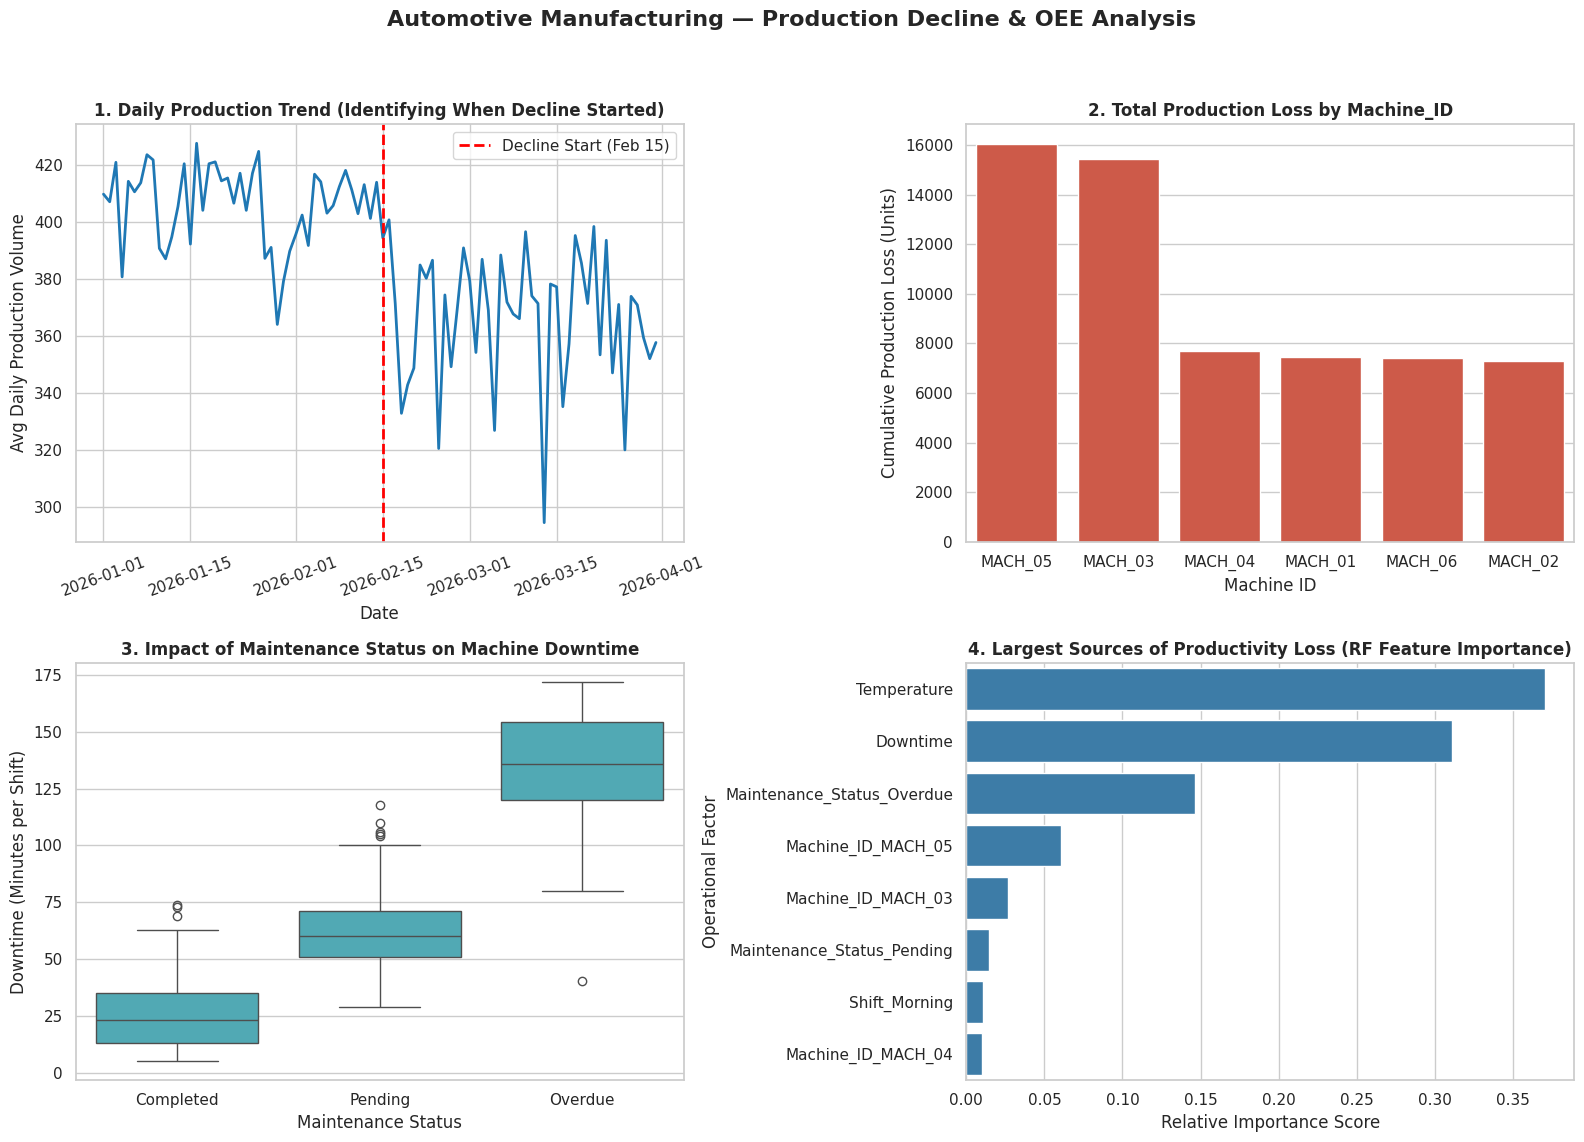

In [4]:
# =====================================================================
# CELL 4: CREATE 4 CLEAR VISUALIZATIONS
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Automotive Manufacturing — Production Decline & OEE Analysis', fontsize=16, fontweight='bold')

# Visualization 1: When the Decline Started (Daily Production Trend)
daily_prod = df.groupby('Date')['Production_Volume'].mean().reset_index()
sns.lineplot(data=daily_prod, x='Date', y='Production_Volume', ax=axes[0, 0], color='#1f78b4', linewidth=2)
axes[0, 0].axvline(pd.Timestamp('2026-02-15'), color='red', linestyle='--', linewidth=2, label='Decline Start (Feb 15)')
axes[0, 0].set_title('1. Daily Production Trend (Identifying When Decline Started)', fontweight='bold')
axes[0, 0].set_ylabel('Avg Daily Production Volume')
axes[0, 0].set_xlabel('Date')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=20)

# Visualization 2: Machines Responsible for Largest Production Losses
mach_order = df.groupby('Machine_ID')['Production_Loss'].sum().sort_values(ascending=False).index
sns.barplot(data=df, x='Machine_ID', y='Production_Loss', estimator=sum, order=mach_order, ax=axes[0, 1], color='#e34a33', errorbar=None)
axes[0, 1].set_title('2. Total Production Loss by Machine_ID', fontweight='bold')
axes[0, 1].set_ylabel('Cumulative Production Loss (Units)')
axes[0, 1].set_xlabel('Machine ID')

# Visualization 3: Relationship Between Maintenance Status & Downtime
maint_order = ['Completed', 'Pending', 'Overdue']
sns.boxplot(data=df, x='Maintenance_Status', y='Downtime', order=maint_order, ax=axes[1, 0], color='#41b6c4')
axes[1, 0].set_title('3. Impact of Maintenance Status on Machine Downtime', fontweight='bold')
axes[1, 0].set_ylabel('Downtime (Minutes per Shift)')
axes[1, 0].set_xlabel('Maintenance Status')

# Visualization 4: Largest Sources of Productivity Loss (RF Feature Importance)
top_factors = feature_importances.head(8)
sns.barplot(data=top_factors, x='Importance_Score', y='Operational_Factor', ax=axes[1, 1], color='#2c7fb8')
axes[1, 1].set_title('4. Largest Sources of Productivity Loss (RF Feature Importance)', fontweight='bold')
axes[1, 1].set_xlabel('Relative Importance Score')
axes[1, 1].set_ylabel('Operational Factor')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()